# Paper-Evaluation — energy-arena Challenge 16 (Solar Ensemble, DE-LU)

**Zweck:** liefert die Zahlen und Abbildungen für das Paper (Abschnitt *Ergebnisse*, TQ1–TQ3),
für das Ziel-Fenster **2026-06-07 – 2026-07-07** (delivery dates).

**Ausschließlich offizielle energy-arena-Daten**, gefroren in `data/eval_cache/` durch
`scripts/fetch_arena_scores.py` (`GET /api/v1/leaderboard/timeseries`, alle Teilnehmer der
Challenge). Der Snapshot liefert je Teilnehmer die von der Plattform berechneten Tages-Scores,
die vollen 100-Member-Ensembles **und** die SMARD-Ground-Truth — daraus folgt alles offline,
reproduzierbar, ohne weiteren API-Call.

- **§1 · Leaderboard-Scores (TQ1)** — Plattform-Tages-CRPS/WIS/Coverage für `spinner` (id 19) vs.
  `NaiveBenchmark` (id 1); §1b scort das **gesamte Teilnehmerfeld** pro Liefertag aus den Membern.
- **§2 · Member-CRPS (Methodik-Cross-Check)** — CRPS aus spinners offiziellen 100 Membern selbst
  gerechnet; reproduziert es die Plattform-CRPS aus §1, ist unsere member-basierte PIT-/Coverage-
  Methodik validiert (die Plattform legt diese nicht auf Member-Ebene offen).
- **§3 · Kalibrierung (TQ2)** und **§4 · Fan-Charts (TQ3)** — aus spinners offiziellem Ensemble.

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import properscoring as ps

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import config

# --- Ziel-Fenster (delivery dates) ---
WIN_START = pd.Timestamp("2026-06-07").date()
WIN_END   = pd.Timestamp("2026-07-07").date()

CACHE = REPO / "data" / "eval_cache"
SLUG  = "ch16_1-2-8-17-19-20-26_2026-06-06_2026-07-07"   # gefrorener Arena-Snapshot (alle Teilnehmer, Liefertage 7.6.-7.7.)
ME, BASELINE, GUENTHER99 = 19, 1, 17
TZ_DELIV = "Europe/Berlin"                        # DE-LU Lieferzone

# Fehlende Submissions: an einem Wettkampftag (= Tag mit NaiveBaseline-Score) ohne eigene
# Submission zählt die Prognose als "nicht besser als Baseline" -> CRPS = Baseline-CRPS, Skill 0.
# True = ehrliche/konservative Zahl (kein stilles Weglassen der Fehltage); False = nur eingereichte Tage.
IMPUTE_MISSING = True

def delivery_date(ts_utc):
    """UTC target_start -> Liefer-Kalendertag (Mitternacht) in der DE-LU-Zone."""
    return pd.DatetimeIndex(pd.to_datetime(ts_utc, utc=True)).tz_convert(TZ_DELIV).normalize()

# --- Figuren-Export fürs Paper (IEEE-Zweispalter: Zielbreite direkt hier setzen,
#     in LaTeX 1:1 mit width=\textwidth einbinden) ---
plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 9, "axes.labelsize": 9,
    "legend.fontsize": 7, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})
FIG_DIR = REPO / "paper" / "tex" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Fenster:", WIN_START, "->", WIN_END)

Fenster: 2026-06-07 -> 2026-07-07


## §1 · Arena-offizielle Scores (TQ1)

Gefrorene Tages-Metriken der Plattform. `target_start` ist UTC-Mitternacht der Lieferzone
(z. B. `…T22:00:00Z` = Liefertag+1), daher rechnen wir auf den Liefertag um und filtern aufs Fenster.

**Wettkampftage = Tage mit NaiveBaseline-Score** (die Plattform lief und Actuals lagen vor). An
solchen Tagen ohne eigene Submission gilt mit `IMPUTE_MISSING=True`: CRPS = Baseline-CRPS → Skill 0
(die Fehltage werden nicht still weggelassen). `Spalte submitted` markiert echte vs. imputierte Tage.

In [4]:
metrics = pd.read_csv(CACHE / f"arena_metrics_{SLUG}.csv")
metrics["delivery"] = delivery_date(metrics["target_start"])
metrics = metrics[metrics["delivery"].dt.date.between(WIN_START, WIN_END)].copy()

me_m   = metrics[metrics.participant_id == ME].set_index("delivery")
base_m = metrics[metrics.participant_id == BASELINE].set_index("delivery").sort_index()

# Wettkampftage = alle Tage mit NaiveBaseline-Score
comp_days = base_m.index
arena = pd.DataFrame(index=comp_days)
arena["crps_me"]       = me_m["CRPS"].reindex(comp_days)
arena["crps_baseline"] = base_m["CRPS"]
arena["wis_me"]        = me_m["WIS"].reindex(comp_days)
arena["cov50_me"]      = me_m["COVERAGE_50"].reindex(comp_days)
arena["cov90_me"]      = me_m["COVERAGE_90"].reindex(comp_days)
arena["submitted"]     = arena["crps_me"].notna()

missing_days = list(arena.index[~arena["submitted"]])
if IMPUTE_MISSING:
    arena["crps_me"] = arena["crps_me"].fillna(arena["crps_baseline"])   # Skill 0 an Fehltagen
else:
    arena = arena[arena["submitted"]]
arena["skill"] = 1.0 - arena["crps_me"] / arena["crps_baseline"]

sub = arena[arena["submitted"]]
print(f"Wettkampftage: {len(arena)}  ({arena.index.min().date()} .. {arena.index.max().date()})")
print(f"  eingereicht: {len(sub)} | fehlend: {len(missing_days)} "
      f"({', '.join(str(d.date()) for d in missing_days) or '—'})  [impute={IMPUTE_MISSING}]")
print(f"mean CRPS spinner   : {arena.crps_me.mean():8.1f} MW")
print(f"mean CRPS NaiveBench : {arena.crps_baseline.mean():8.1f} MW")
print(f"mean daily skill (eingereicht): {sub.skill.mean():+.3f}")
print(f"pooled skill (nur eingereicht): {1 - sub.crps_me.mean()/sub.crps_baseline.mean():+.3f}")
print(f"pooled skill (impute Naive)   : {1 - arena.crps_me.mean()/arena.crps_baseline.mean():+.3f}")
arena.round(2)

Wettkampftage: 31  (2026-06-07 .. 2026-07-07)
  eingereicht: 28 | fehlend: 3 (2026-06-13, 2026-06-20, 2026-06-28)  [impute=True]
mean CRPS spinner   :   1788.7 MW
mean CRPS NaiveBench :   4538.1 MW
mean daily skill (eingereicht): +0.503
pooled skill (nur eingereicht): +0.647
pooled skill (impute Naive)   : +0.606


,crps_me,crps_baseline,wis_me,cov50_me,cov90_me,submitted,skill
delivery,,,,,,,
2026-06-07 00:00:00+02:00,1570.23,5154.93,1425.57,23.96,40.62,True,0.70
2026-06-08 00:00:00+02:00,984.02,4497.52,915.58,48.96,55.21,True,0.78
2026-06-09 00:00:00+02:00,1770.09,7210.75,1591.99,28.12,43.75,True,0.75
2026-06-10 00:00:00+02:00,1392.49,3384.30,1257.72,52.08,57.29,True,0.59
2026-06-11 00:00:00+02:00,1613.38,2273.92,1456.58,39.58,54.17,True,0.29
2026-06-12 00:00:00+02:00,1379.91,8664.33,1193.55,42.71,56.25,True,0.84
2026-06-13 00:00:00+02:00,2017.83,2017.83,NaN,NaN,NaN,False,0.00
2026-06-14 00:00:00+02:00,1927.18,843.96,1711.22,27.08,50.00,True,-1.28
2026-06-15 00:00:00+02:00,1741.35,3449.04,1559.90,33.33,53.12,True,0.50


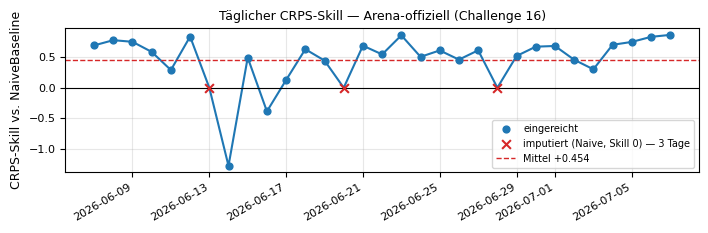

In [5]:
# Täglicher Skill-Verlauf (Abbildung TQ1); imputierte Fehltage markiert
fig, ax = plt.subplots(figsize=(7.16, 2.4))
ax.plot(arena.index, arena["skill"], "-", color="#1f77b4", lw=1.5)
ax.scatter(sub.index, sub["skill"], color="#1f77b4", s=24, zorder=3, label="eingereicht")
imp = arena[~arena["submitted"]]
if len(imp):
    ax.scatter(imp.index, imp["skill"], color="#d62728", s=40, marker="x", zorder=4,
               label=f"imputiert (Naive, Skill 0) — {len(imp)} Tage")
ax.axhline(0, color="k", lw=0.8)
ax.axhline(arena["skill"].mean(), color="#d62728", ls="--", lw=1,
           label=f"Mittel {arena['skill'].mean():+.3f}")
ax.set_ylabel("CRPS-Skill vs. NaiveBaseline")
ax.set_title("Täglicher CRPS-Skill — Arena-offiziell (Challenge 16)")
ax.legend(fontsize=7); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout()
fig.savefig(FIG_DIR / "skill_daily.pdf")

In [6]:
# §1b · Feld-Skill vs. NaiveBaseline — alle Teilnehmer (aus dem all-Member-Snapshot)
# Nur spinner hat eine eigene Metrik-CSV; die übrigen Teilnehmer werden pro Liefertag aus
# ihren 100-Member-Ensembles selbst gescort. Pooled Skill wie §1: "eingereicht" (nur eigene
# Tage) und "impute" (Fehltage -> Naive-CRPS, Skill 0). spinner dient als Cross-Check gegen
# §1 (~0.616 / ~0.567). Simon_Electricity (id 20) fehlt im Fenster (nur 1/90 Tagen aktiv).
import json as _json
_all = _json.load(open(CACHE / f"arena_ts_{SLUG}.json"))
_gt = pd.Series({pd.Timestamp(x["ts"]): x["value"] for x in _all["ground_truth"]}).sort_index()
_gt.index = _gt.index.tz_convert("UTC")

def _ens(pid):
    p = next(x for x in _all["participants"] if x["participant_id"] == pid)
    idx = pd.to_datetime([e["ts"] for e in p["ensemble_points"]], utc=True)
    F = pd.DataFrame([e["values"] for e in p["ensemble_points"]], index=idx).sort_index()
    dd = F.index.tz_convert(TZ_DELIV).normalize()
    return F[(dd.date >= WIN_START) & (dd.date <= WIN_END)]

def _daily_crps(F):
    idx = F.index.intersection(_gt.dropna().index)
    o, fv = _gt.reindex(idx), F.reindex(idx).values
    v = ~o.isna().values & ~np.isnan(fv).any(1)
    s = pd.Series(ps.crps_ensemble(o.values[v], fv[v]), index=idx[v])
    return s.groupby(s.index.tz_convert(TZ_DELIV).normalize()).mean()

naive_daily = _daily_crps(_ens(BASELINE))
field_comp_days = naive_daily.index            # Wettkampftage = Tage mit Naive-Score

def field_skill(pid):
    p_daily = _daily_crps(_ens(pid)).reindex(field_comp_days)
    submitted = p_daily.notna()
    p_imp = p_daily.fillna(naive_daily)         # Fehltage -> Naive-CRPS (Skill 0)
    return {
        "Wettkampftage": len(field_comp_days),
        "eingereicht":   int(submitted.sum()),
        "mean CRPS":     p_daily[submitted].mean(),
        "Skill (eingereicht)": 1 - p_daily[submitted].mean() / naive_daily[submitted].mean(),
        "Skill (impute)":      1 - p_imp.mean() / naive_daily.mean(),
    }

# alle Teilnehmer außer der Baseline, absteigend nach pooled Skill
_field = [(p["participant_id"], p["participant_name"])
          for p in _all["participants"] if p["participant_id"] != BASELINE]
field_skill_df = (pd.DataFrame({nm: field_skill(pid) for pid, nm in _field}).T
                  .sort_values("Skill (impute)", ascending=False))
print("CRPS-Skill vs. NaiveBaseline (all-Member-Snapshot, pro Liefertag):")
print(field_skill_df.round(3).to_string())
field_skill_df.round(3)

CRPS-Skill vs. NaiveBaseline (all-Member-Snapshot, pro Liefertag):
              Wettkampftage  eingereicht  mean CRPS  Skill (eingereicht)  Skill (impute)
spinner                31.0         28.0   1659.798                0.647           0.606
guenther99             31.0         29.0   2463.753                0.462           0.435
Mkay                   31.0         29.0   3567.102                0.221           0.208
OpenForecast           31.0         29.0   3567.102                0.221           0.208
Wetterfrosch           31.0         24.0  18530.321               -3.147          -2.399


,Wettkampftage,eingereicht,mean CRPS,Skill (eingereicht),Skill (impute)
spinner,31.0,28.0,1659.798,0.647,0.606
guenther99,31.0,29.0,2463.753,0.462,0.435
Mkay,31.0,29.0,3567.102,0.221,0.208
OpenForecast,31.0,29.0,3567.102,0.221,0.208
Wetterfrosch,31.0,24.0,18530.321,-3.147,-2.399


## §2 · Member-CRPS aus dem offiziellen Ensemble (Methodik-Cross-Check)

Spinners **offizielle 100 Member** aus dem Arena-Snapshot, pro Liefertag gegen die (ebenfalls
offizielle) SMARD-Ground-Truth selbst gescort. Die Tages-CRPS werden gegen die Plattform-CRPS aus
§1 gehalten: stimmen beide überein (Δ ≈ 0 %), reproduziert unsere member-basierte Scoring-Pipeline
die Arena-Zahlen exakt — womit die daraus abgeleiteten PIT-/Coverage-Werte (§3), die die Plattform
nicht auf Member-Ebene ausgibt, methodisch abgesichert sind. Hier fallen zugleich die pro-Slot-PIT-
und Coverage-Arrays für §3 an.

In [7]:
# spinners offizielles 100-Member-Ensemble aus dem Snapshot (_all, _gt kommen aus §1b)
spinner = next(p for p in _all["participants"] if p["participant_id"] == ME)
spin_F = pd.DataFrame(
    [e["values"] for e in spinner["ensemble_points"]],
    index=pd.to_datetime([e["ts"] for e in spinner["ensemble_points"]], utc=True),
).sort_index()
obs_all = _gt.reindex(spin_F.index)                 # SMARD-Ground-Truth auf dem Ensemble-Raster

rows, pit_full_all, pit_day_all = [], [], []
cover_full = {0.5: [], 0.9: []}     # Coverage mit Nacht (alle Slots)
cover_day  = {0.5: [], 0.9: []}     # Coverage ohne Nacht (nur Tageslicht)
for day, F in spin_F.groupby(spin_F.index.tz_convert(TZ_DELIV).normalize()):
    if not (WIN_START <= day.date() <= WIN_END):
        continue
    o = obs_all.reindex(F.index)
    valid = ~o.isna().values & ~np.isnan(F.values).any(axis=1)
    if valid.sum() < 96 - 8:            # zu viele fehlende Slots -> Tag auslassen
        continue
    ov, fv = o.values[valid], F.values[valid]
    rows.append({
        "delivery":  day,
        "crps_self": float(ps.crps_ensemble(ov, fv).mean()),
        "n_slots":   int(valid.sum()),
    })
    # PIT für §3: Anteil Member unter Beobachtung; Tageslicht = Ensemble-Spread > 0 (Nacht raus)
    is_day = fv.max(axis=1) > 0
    pit = np.array([np.mean(fv[i] < ov[i]) for i in range(len(ov))])
    pit_full_all.append(pit)
    pit_day_all.append(pit[is_day])
    # Coverage mit/ohne Nacht: Ist im zentralen lv-Intervall der 100 Member
    for lv in (0.5, 0.9):
        lo = np.quantile(fv, (1 - lv) / 2, axis=1)
        hi = np.quantile(fv, 1 - (1 - lv) / 2, axis=1)
        inside = (ov >= lo) & (ov <= hi)
        cover_full[lv].append(inside)
        cover_day[lv].append(inside[is_day])

self_df = pd.DataFrame(rows).set_index("delivery")

# gegen Arena halten (beide Indizes sind Liefer-Mitternacht Berlin)
cmp = self_df.join(arena[["crps_me", "crps_baseline"]], how="left")
cmp["crps_arena"] = cmp["crps_me"]
cmp["skill_self"] = 1.0 - cmp["crps_self"] / cmp["crps_baseline"]
cmp["rel_diff_%"] = 100 * (cmp["crps_self"] - cmp["crps_arena"]) / cmp["crps_arena"]

print(f"Selbst gescorte Tage (offizielle Member): {len(self_df)}")
print(f"mean self-CRPS       : {self_df.crps_self.mean():8.1f} MW")
print(f"mean arena-CRPS       : {cmp['crps_arena'].mean():8.1f} MW")
print(f"mean |rel. Abweichung|: {cmp['rel_diff_%'].abs().mean():.3f} %  (self vs. arena; ~0 => Methodik reproduziert Arena)")
print(f"pooled self-skill    : {1 - self_df.crps_self.mean()/cmp['crps_baseline'].mean():+.3f}")
cmp[["crps_self", "crps_arena", "rel_diff_%", "crps_baseline", "skill_self", "n_slots"]].round(2)

Selbst gescorte Tage (offizielle Member): 28
mean self-CRPS       :   1659.8 MW
mean arena-CRPS       :   1659.8 MW
mean |rel. Abweichung|: 0.000 %  (self vs. arena; ~0 => Methodik reproduziert Arena)
pooled self-skill    : +0.647


,crps_self,crps_arena,rel_diff_%,crps_baseline,skill_self,n_slots
delivery,,,,,,
2026-06-07 00:00:00+02:00,1570.23,1570.23,-0.0,5154.93,0.70,96
2026-06-08 00:00:00+02:00,984.02,984.02,0.0,4497.52,0.78,96
2026-06-09 00:00:00+02:00,1770.09,1770.09,0.0,7210.75,0.75,96
2026-06-10 00:00:00+02:00,1392.49,1392.49,-0.0,3384.30,0.59,96
2026-06-11 00:00:00+02:00,1613.38,1613.38,-0.0,2273.92,0.29,96
2026-06-12 00:00:00+02:00,1379.91,1379.91,0.0,8664.33,0.84,96
2026-06-14 00:00:00+02:00,1927.18,1927.18,0.0,843.96,-1.28,96
2026-06-15 00:00:00+02:00,1741.35,1741.35,0.0,3449.04,0.50,96
2026-06-16 00:00:00+02:00,1511.47,1511.47,-0.0,1088.39,-0.39,96


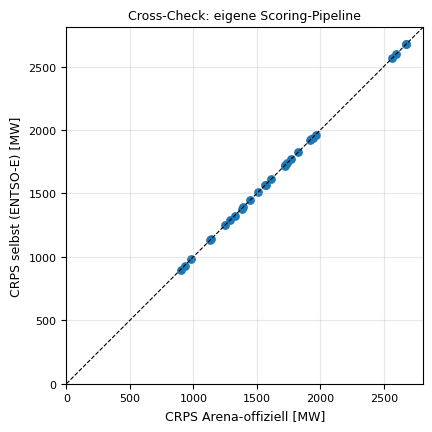

In [8]:
# self vs. arena CRPS pro Tag (sollte auf der Diagonalen liegen)
fig, ax = plt.subplots(figsize=(4.4, 4.4))
lim = [0, max(cmp["crps_self"].max(), cmp["crps_arena"].max()) * 1.05]
ax.plot(lim, lim, "k--", lw=0.8)
ax.scatter(cmp["crps_arena"], cmp["crps_self"], color="#1f77b4", s=28)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("CRPS Arena-offiziell [MW]")
ax.set_ylabel("CRPS selbst (ENTSO-E) [MW]")
ax.set_title("Cross-Check: eigene Scoring-Pipeline")
ax.grid(alpha=0.3); plt.tight_layout()

## §3 · Kalibrierung — PIT & Dispersion (TQ2)

Gepoolte, rangbasierte PIT-Werte. Ein kalibriertes Ensemble liefert ein flaches Histogramm;
U-Form = unterdispersiv. **Zwei Ansichten:**

- **Alle Slots** — die Spitze bei PIT=1.0 ist ein *Nacht-Artefakt*: nachts sind alle 100 Member
  exakt 0 (physik. Nacht-Nullung), die ENTSO-E-Aktuals haben aber einen kleinen Messsockel (>0),
  also liegt die Beobachtung über allen Membern → PIT=1.0. Misst nicht die Kalibrierung.
- **Nur Tageslicht** (Ensemble-Spread > 0, Nacht ausgeschlossen) — die belastbare Kalibrierungs-Aussage.

**Coverage** (50/90 %) wird zusätzlich zur Arena-Coverage (nur Tageslicht) selbst gerechnet —
jeweils **mit und ohne Nacht**. Die *mit-Nacht*-Variante enthält denselben Nacht-Nullungs-Effekt
(Member = 0, Ist > 0 → Beobachtung außerhalb des 0-Intervalls) und liegt daher künstlich niedriger;
belastbar ist die *ohne-Nacht*-Variante.

Die daytime-Werte gehen ins §5-Summary; die Arena-Coverage bestätigt unabhängig.

ALLE Slots     : PIT-Bias +0.218  Dispersion 1.183   
nur Tageslicht : PIT-Bias +0.106  Dispersion 1.195   
Coverage 50 (Ziel 50): ohne Nacht  40.7  |  mit Nacht  29.1
Coverage 90 (Ziel 90): ohne Nacht  59.9  |  mit Nacht  42.8   (mit Nacht: Nacht-Nullung senkt Coverage künstlich)
Arena COVERAGE_50 (Ziel 50, nur Tageslicht): 29.1
Arena COVERAGE_90 (Ziel 90, nur Tageslicht): 42.8


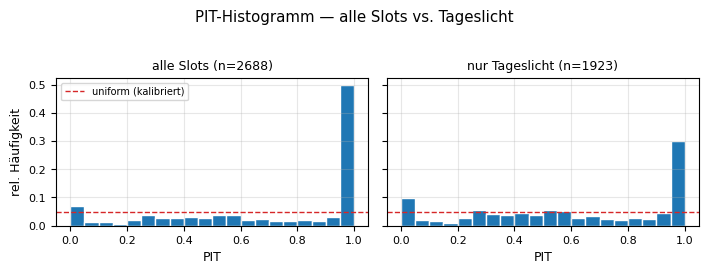

In [9]:
def pit_stats(p):
    return p.mean() - 0.5, p.std() / (1 / np.sqrt(12))   # (bias, dispersion-ratio)

pit_full = np.concatenate(pit_full_all)
pit_day  = np.concatenate(pit_day_all)
bias_full, disp_full = pit_stats(pit_full)
bias_day,  disp_day  = pit_stats(pit_day)

# Coverage selbst gerechnet, ohne Nacht (nur Tageslicht) und mit Nacht (alle Slots)
cov_self = {lv: (100 * np.concatenate(cover_day[lv]).mean(),      # ohne Nacht
                 100 * np.concatenate(cover_full[lv]).mean())     # mit Nacht
            for lv in (0.5, 0.9)}

fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.6), sharey=True)
for ax, p, ttl in [(axes[0], pit_full, f"alle Slots (n={len(pit_full)})"),
                   (axes[1], pit_day,  f"nur Tageslicht (n={len(pit_day)})")]:
    ax.hist(p, bins=20, range=(0, 1), color="#1f77b4", edgecolor="white",
            weights=np.ones_like(p) / len(p))
    ax.axhline(1 / 20, color="#d62728", ls="--", lw=1)
    ax.set_xlabel("PIT"); ax.set_title(ttl); ax.grid(alpha=0.3)
axes[0].set_ylabel("rel. Häufigkeit")
axes[0].plot([], [], color="#d62728", ls="--", lw=1, label="uniform (kalibriert)")
axes[0].legend(fontsize=7)
fig.suptitle("PIT-Histogramm — alle Slots vs. Tageslicht", y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / "pit.pdf")

# fürs §5-Summary: die belastbaren Tageslicht-Werte
pit_bias, disp_ratio = bias_day, disp_day

print(f"ALLE Slots     : PIT-Bias {bias_full:+.3f}  Dispersion {disp_full:.3f}   ")
print(f"nur Tageslicht : PIT-Bias {bias_day:+.3f}  Dispersion {disp_day:.3f}   ")
print(f"Coverage 50 (Ziel 50): ohne Nacht {cov_self[0.5][0]:5.1f}  |  mit Nacht {cov_self[0.5][1]:5.1f}")
print(f"Coverage 90 (Ziel 90): ohne Nacht {cov_self[0.9][0]:5.1f}  |  mit Nacht {cov_self[0.9][1]:5.1f}   (mit Nacht: Nacht-Nullung senkt Coverage künstlich)")
print(f"Arena COVERAGE_50 (Ziel 50, nur Tageslicht): {arena['cov50_me'].mean():.1f}")
print(f"Arena COVERAGE_90 (Ziel 90, nur Tageslicht): {arena['cov90_me'].mean():.1f}")

## §4 · Fan-Charts — guter vs. schwieriger Tag (TQ3)

Bester und schwächster Tag nach Arena-Skill. Ensemble-Bänder (5–95 %, 25–75 %) + Median vs. Ist.

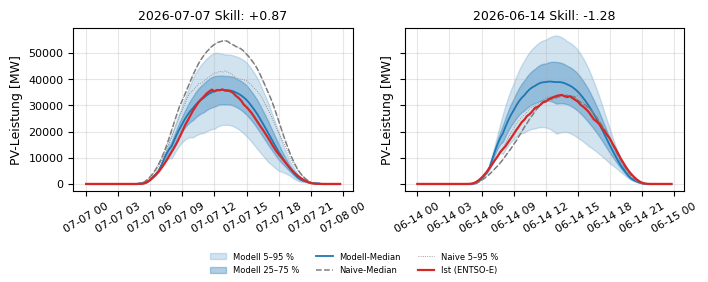

In [10]:
# NaiveBaseline-Ensemble (100 Member, 15-min) aus dem gefrorenen Arena-Snapshot
naive = next(p for p in _all["participants"] if p["participant_id"] == BASELINE)
naive_ens = pd.DataFrame(
    [e["values"] for e in naive["ensemble_points"]],
    index=pd.to_datetime([e["ts"] for e in naive["ensemble_points"]], utc=True),
).sort_index()

def fan_chart(ax, day, title):
    F = spin_F[spin_F.index.tz_convert(TZ_DELIV).normalize() == day]     # spinners offizielle Member
    o = obs_all.reindex(F.index)
    t = F.index.tz_convert(TZ_DELIV)
    q = np.nanpercentile(F.values, [5, 25, 50, 75, 95], axis=1)
    ax.fill_between(t, q[0], q[4], color="#1f77b4", alpha=0.20, label="Modell 5–95 %")
    ax.fill_between(t, q[1], q[3], color="#1f77b4", alpha=0.35, label="Modell 25–75 %")
    ax.plot(t, q[2], color="#1f77b4", lw=1.3, label="Modell-Median")
    # NaiveBaseline: Median (gestrichelt) + 5–95-Hülle (gepunktet) auf demselben Slot-Raster
    nb = naive_ens.reindex(F.index).values
    nq = np.nanpercentile(nb, [5, 50, 95], axis=1)
    ax.plot(t, nq[1], color="#7f7f7f", lw=1.1, ls="--", label="Naive-Median")
    ax.plot(t, nq[0], color="#7f7f7f", lw=0.6, ls=":")
    ax.plot(t, nq[2], color="#7f7f7f", lw=0.6, ls=":", label="Naive 5–95 %")
    ax.plot(t, o.values, color="#d62728", lw=1.6, label="Ist (ENTSO-E)")
    ax.set_title(title); ax.set_ylabel("PV-Leistung [MW]")
    ax.grid(alpha=0.3)

best  = sub["skill"].idxmax()   # bester/schwächster eingereichter Tag nach Arena-Skill
worst = sub["skill"].idxmin()
fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.8), sharey=True)
fan_chart(axes[0], best,  f"{best:%Y-%m-%d} Skill: {arena.loc[best,'skill']:+.2f}")
fan_chart(axes[1], worst, f"{worst:%Y-%m-%d} Skill: {arena.loc[worst,'skill']:+.2f}")
handles, labels = axes[0].get_legend_handles_labels()
for a in axes: a.tick_params(axis="x", rotation=30)
plt.tight_layout(rect=[0, 0.10, 1, 1])
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=6, frameon=False)
fig.savefig(FIG_DIR / "fanchart.pdf")

## §5 · Zahlen fürs Paper

Kompakte Zusammenfassung der Kennzahlen, die direkt in Abstract / §Ergebnisse gehören.

In [11]:
summary = {
    "Fenster":                 f"{WIN_START} .. {WIN_END}",
    "Wettkampftage":           len(arena),
    "davon eingereicht":       int(arena["submitted"].sum()),
    "davon imputiert (Naive)": int((~arena["submitted"]).sum()),
    "impute-Modus":            IMPUTE_MISSING,
    "mean CRPS spinner [MW]":  round(arena.crps_me.mean(), 1),
    "mean CRPS Naive [MW]":    round(arena.crps_baseline.mean(), 1),
    "pooled Skill (eingereicht)": round(1 - sub.crps_me.mean()/sub.crps_baseline.mean(), 3),
    "pooled Skill (impute)":   round(1 - arena.crps_me.mean()/arena.crps_baseline.mean(), 3),
    "mean daily Skill (eingereicht)": round(sub.skill.mean(), 3),
    "self vs arena |Δ| [%]":   round(cmp["rel_diff_%"].abs().mean(), 2),
    "PIT-Bias (Tageslicht)":   round(bias_day, 3),
    "Dispersion (Tageslicht)": round(disp_day, 3),
    "PIT-Bias (alle Slots)":   round(bias_full, 3),
    "Dispersion (alle Slots)": round(disp_full, 3),
    "COVERAGE_50 (Ziel 50)":   round(arena['cov50_me'].mean(), 1),
    "COVERAGE_90 (Ziel 90)":   round(arena['cov90_me'].mean(), 1),
    "COVERAGE_50 self (o. Nacht)": round(cov_self[0.5][0], 1),
    "COVERAGE_50 self (m. Nacht)": round(cov_self[0.5][1], 1),
    "COVERAGE_90 self (o. Nacht)": round(cov_self[0.9][0], 1),
    "COVERAGE_90 self (m. Nacht)": round(cov_self[0.9][1], 1),
}
for k, v in summary.items():
    print(f"{k:28s}: {v}")

# optional als CSV fürs Paper
out = REPO / "paper" / "results_ch16_window.csv"
pd.Series(summary).to_frame("value").to_csv(out)
print("\n->", out)

Fenster                     : 2026-06-07 .. 2026-07-07
Wettkampftage               : 31
davon eingereicht           : 28
davon imputiert (Naive)     : 3
impute-Modus                : True
mean CRPS spinner [MW]      : 1788.7
mean CRPS Naive [MW]        : 4538.1
pooled Skill (eingereicht)  : 0.647
pooled Skill (impute)       : 0.606
mean daily Skill (eingereicht): 0.503
self vs arena |Δ| [%]       : 0.0
PIT-Bias (Tageslicht)       : 0.106
Dispersion (Tageslicht)     : 1.195
PIT-Bias (alle Slots)       : 0.218
Dispersion (alle Slots)     : 1.183
COVERAGE_50 (Ziel 50)       : 29.1
COVERAGE_90 (Ziel 90)       : 42.8
COVERAGE_50 self (o. Nacht) : 40.7
COVERAGE_50 self (m. Nacht) : 29.1
COVERAGE_90 self (o. Nacht) : 59.9
COVERAGE_90 self (m. Nacht) : 42.8

-> /Users/frederikeickenbusch/programming/forecasting_challenge/solar-forecast/paper/results_ch16_window.csv
